# 作物収量・地域・年・気象条件の分析

run_id: `v020-exp-46`。観察データの記述・関連分析に限定し、施策効果は推定しません。取得・分析・図表・監査の実行はJupyter MCPのみ。認証情報は保存・表示しません。

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from contextlib import contextmanager, redirect_stdout, redirect_stderr
from dataclasses import asdict
import sys, os, json, io, hashlib, warnings, nbformat
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
from ai_data_scientist import project_manager, lifecycle, language_router
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-46-crop-yield')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
run_id = 'v020-exp-46'
lifecycle.register_run(run_id, handle.notebook_path)
phase_log = []
@contextmanager
def phase(name):
    if lifecycle.is_cancel_requested(run_id):
        raise RuntimeError('実行の取消し要求を検出')
    lifecycle.mark_execution_start(run_id)
    phase_log.append({'phase': name, 'event': 'start', 'time': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception as exc:
        lifecycle.mark_failed(run_id)
        phase_log.append({'phase': name, 'event': 'failed', 'error_type': type(exc).__name__})
        raise
    finally:
        lifecycle.mark_execution_end(run_id)
        phase_log.append({'phase': name, 'event': 'end', 'time': datetime.now(timezone.utc).isoformat()})
def write_notebook(mutation):
    lifecycle.mark_write_start(run_id)
    phase_log.append({'phase': 'Notebook書込み', 'event': 'write_start', 'time': datetime.now(timezone.utc).isoformat()})
    try:
        return project_manager.enqueue_write(handle, mutation)
    finally:
        lifecycle.mark_write_end(run_id)
        phase_log.append({'phase': 'Notebook書込み', 'event': 'write_end', 'time': datetime.now(timezone.utc).isoformat()})
print('run_id=', run_id, '言語=', language_router.detect_language('作物収量データを分析してください'))


run_id= v020-exp-46 言語= ja


In [2]:
# Kaggle認証ログと例外本文は出力しない（認証情報漏えい防止）
api_log = []
search_results = []
api = None
with phase('Kaggle認証・公開データ検索'):
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
        api_log.append({'step': 'authenticate', 'ok': True})
        for query in ['crop yield weather', 'crop yield prediction']:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                found = api.dataset_list(search=query)
            records = [{'query': query, 'slug': d.ref, 'title': d.title, 'size': getattr(d, 'totalBytes', None)} for d in found]
            search_results.extend(records)
            api_log.append({'step': 'dataset_list', 'query': query, 'ok': True, 'count': len(records)})
    except Exception as exc:
        api_log.append({'step': 'Kaggle検索', 'ok': False, 'error_type': type(exc).__name__, 'http_status': getattr(getattr(exc, 'response', None), 'status_code', None)})
        api = None
print(json.dumps({'api_log': api_log, 'public_search_results': search_results}, ensure_ascii=False, indent=2))


{
  "api_log": [
    {
      "step": "authenticate",
      "ok": true
    },
    {
      "step": "dataset_list",
      "query": "crop yield weather",
      "ok": true,
      "count": 20
    },
    {
      "step": "dataset_list",
      "query": "crop yield prediction",
      "ok": true,
      "count": 20
    }
  ],
  "public_search_results": [
    {
      "query": "crop yield weather",
      "slug": "patelris/crop-yield-prediction-dataset",
      "title": "🌾 Crop Yield Prediction Dataset",
      "size": null
    },
    {
      "query": "crop yield weather",
      "slug": "samuelotiattakorah/agriculture-crop-yield",
      "title": "Agriculture Crop Yield",
      "size": null
    },
    {
      "query": "crop yield weather",
      "slug": "varshitanalluri/crop-recommendation-dataset",
      "title": "Crop Recommendation Dataset",
      "size": null
    },
    {
      "query": "crop yield weather",
      "slug": "govindaramsriram/crop-yield-of-a-farm",
      "title": "Crop Yield of a Farm"

In [3]:
import inspect
with phase('候補データのファイルと定義確認'):
    print('dataset_metadata signature:', inspect.signature(api.dataset_metadata))
    candidates = ['patelris/crop-yield-prediction-dataset', 'zoya77/indian-historical-crop-yield-and-weather-data', 'madhankumar789/crop-yield-and-environmental-factors-2014-2023']
    candidate_files = {}
    for slug in candidates:
        try:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                listing = api.dataset_list_files(slug)
            files = [{'name': f.name, 'bytes': getattr(f, 'total_bytes', None)} for f in listing.files]
            candidate_files[slug] = files
            api_log.append({'step': 'dataset_list_files', 'slug': slug, 'ok': True, 'files': files})
        except Exception as exc:
            api_log.append({'step': 'dataset_list_files', 'slug': slug, 'ok': False, 'error_type': type(exc).__name__})
    print(json.dumps(candidate_files, ensure_ascii=False, indent=2))
    selected_slug = 'patelris/crop-yield-prediction-dataset'
    metadata_dir = data_dir / 'metadata'
    metadata_dir.mkdir(exist_ok=True)
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        api.dataset_metadata(selected_slug, path=str(metadata_dir))
    metadata_paths = list(metadata_dir.glob('*.json'))
    public_metadata = json.loads(metadata_paths[0].read_text())
    print('公開メタデータ:', json.dumps(public_metadata, ensure_ascii=False, indent=2)[:18000])


dataset_metadata signature: (dataset, path)
{
  "patelris/crop-yield-prediction-dataset": [
    {
      "name": "pesticides.csv",
      "bytes": 447677
    },
    {
      "name": "rainfall.csv",
      "bytes": 136712
    },
    {
      "name": "temp.csv",
      "bytes": 1421414
    },
    {
      "name": "yield.csv",
      "bytes": 4042934
    },
    {
      "name": "yield_df.csv",
      "bytes": 1565376
    }
  ],
  "zoya77/indian-historical-crop-yield-and-weather-data": [
    {
      "name": "Custom_Crops_yield_Historical_Dataset.csv",
      "bytes": 7576519
    }
  ],
  "madhankumar789/crop-yield-and-environmental-factors-2014-2023": [
    {
      "name": "crop_yield_dataset.csv",
      "bytes": 4737863
    }
  ]
}
公開メタデータ: {
  "info": {
    "datasetId": 1760177,
    "datasetSlug": "crop-yield-prediction-dataset",
    "ownerUser": "patelris",
    "usabilityRating": 1,
    "totalViews": 267154,
    "totalVotes": 344,
    "totalDownloads": 63630,
    "title": "🌾 Crop Yield Prediction 

# データ選定と取得方針

検索結果の `patelris/crop-yield-prediction-dataset` は10作物の収量・国・年・降水量・気温を含み、FAO/World Bank由来との公開説明があるため採用します。合成データの可能性を避けるため、単に名称が一致する他候補へ変更せず、統合表と元の4表を同一slugから取得して単位・結合粒度を検証します。取得に失敗した場合のみ指定white-paperの同じデータの明示CSVを検討します。

In [4]:
import pandas as pd
import numpy as np
import zipfile
provenance = []
frames = {}
acquisition_ok = True
with phase('Kaggle CSV取得・SHA-256・スキーマ確認'):
    if api is None:
        acquisition_ok = False
    else:
        for filename in ['yield_df.csv', 'yield.csv', 'rainfall.csv', 'temp.csv', 'pesticides.csv']:
            dest = data_dir / filename
            try:
                if not dest.exists():
                    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                        api.dataset_download_file(selected_slug, filename, path=str(data_dir), force=True, quiet=True)
                    zipped = data_dir / (filename + '.zip')
                    if not dest.exists() and zipped.exists():
                        with zipfile.ZipFile(zipped) as archive:
                            matches = [n for n in archive.namelist() if Path(n).name == filename]
                            if len(matches) != 1:
                                raise ValueError('CSV名の一致が一意ではありません')
                            dest.write_bytes(archive.read(matches[0]))
                if not dest.exists():
                    raise FileNotFoundError('要求CSVが保存されていません')
                sidecar = data_dir / (filename + '.provenance.json')
                digest = hashlib.sha256(dest.read_bytes()).hexdigest()
                if sidecar.exists():
                    record = json.loads(sidecar.read_text())
                    if record['sha256'] != digest:
                        raise ValueError('保存済みファイルのSHA-256不一致')
                    record['reuse_verified_at_utc'] = datetime.now(timezone.utc).isoformat()
                else:
                    record = {'owner_dataset_slug': selected_slug, 'filename': filename, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': digest, 'bytes': dest.stat().st_size, 'source_url': 'https://www.kaggle.com/datasets/' + selected_slug}
                    sidecar.write_text(json.dumps(record, ensure_ascii=False, indent=2))
                provenance.append(record)
                frames[filename] = pd.read_csv(dest)
                api_log.append({'step': 'dataset_download_file', 'filename': filename, 'ok': True, 'sha256': digest})
            except Exception as exc:
                acquisition_ok = False
                api_log.append({'step': 'dataset_download_file', 'filename': filename, 'ok': False, 'error_type': type(exc).__name__, 'http_status': getattr(getattr(exc, 'response', None), 'status_code', None)})
                break
    if not acquisition_ok:
        whitepaper = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
        print('取得失敗。white-paper存在:', whitepaper.exists())
        if whitepaper.exists():
            text = whitepaper.read_text()
            lines = text.splitlines()
            hits = [i for i, line in enumerate(lines) if 'crop' in line.lower() or selected_slug in line]
            print('対応データの記載候補:', '\n'.join(lines[max(0, i-2):i+4][j] for i in hits for j in range(len(lines[max(0, i-2):i+4])))[:15000])
        lifecycle.mark_failed(run_id)
    print('取得履歴:', json.dumps(provenance, ensure_ascii=False, indent=2))
    for filename, frame in frames.items():
        print('FILE', filename, 'shape', frame.shape, 'columns', list(frame.columns))
        print(frame.head(3).to_string(index=False))
        print('欠測数:', frame.isna().sum().to_dict())


取得履歴: [
  {
    "owner_dataset_slug": "patelris/crop-yield-prediction-dataset",
    "filename": "yield_df.csv",
    "retrieved_at_utc": "2026-10-01T23:17:31.108157+00:00",
    "sha256": "3d47d3fdc35950b5333348c0d28dbe5534346237813dd1db9d4c26f2935d888b",
    "bytes": 1565376,
    "source_url": "https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset",
    "reuse_verified_at_utc": "2026-10-01T23:28:09.786136+00:00"
  },
  {
    "owner_dataset_slug": "patelris/crop-yield-prediction-dataset",
    "filename": "yield.csv",
    "retrieved_at_utc": "2026-10-01T23:17:33.278856+00:00",
    "sha256": "ddd4855e82cc072433555c972fef6728a05b28f17651221aeb5aac9136ec358c",
    "bytes": 4042934,
    "source_url": "https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset",
    "reuse_verified_at_utc": "2026-10-01T23:28:09.818409+00:00"
  },
  {
    "owner_dataset_slug": "patelris/crop-yield-prediction-dataset",
    "filename": "rainfall.csv",
    "retrieved_at_utc": "2026-10-

# 単位・地域粒度・欠測・結合重複の確認

収量は元表のUnitで検証し、1 hg/ha = 0.0001 t/haに変換します。降水の列名は年平均を示しますが、国別に時間変動があるかを検査します。気温の国年キー重複は観測地点の識別子が失われた可能性があるため、統合表の行を独立した農地観測とみなしません。

In [5]:
from ai_data_scientist import ingestion, cleaning, eda, data_quality, data_definition, analysis_assumptions
from IPython.display import display
with phase('定義・欠測・意味的異常検査'):
    if not acquisition_ok:
        raise RuntimeError('対応データ取得失敗のため分析を停止')
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(data_dir / 'yield_df.csv')), row_limit=100000)
    assert not loaded.truncated
    raw = loaded.dataframe.drop(columns=['Unnamed: 0'])
    clean_report = cleaning.clean_dataset(raw, operation='drop_duplicates')
    dedup = clean_report.dataframe.copy()
    exploration = eda.explore(raw)
    key = ['Area', 'Item', 'Year']
    keycheck = raw.groupby(key).agg(rows=('avg_temp', 'size'), yield_n=('hg/ha_yield', 'nunique'), rain_n=('average_rain_fall_mm_per_year', 'nunique'), pest_n=('pesticides_tonnes', 'nunique'), temp_n=('avg_temp', 'nunique'))
    assert (keycheck[['yield_n', 'rain_n', 'pest_n']] <= 1).all().all()
    reference_yield = frames['yield.csv']
    assert set(reference_yield['Unit']) == {'hg/ha'}
    assert not reference_yield.duplicated(key).any()
    unitcheck = raw.merge(reference_yield[key + ['Value']], on=key, how='left', validate='many_to_one')
    assert unitcheck['Value'].notna().all() and (unitcheck['Value'] == unitcheck['hg/ha_yield']).all()
    rainfall = frames['rainfall.csv'].rename(columns=lambda c: c.strip()).copy()
    rainfall['average_rain_fall_mm_per_year'] = pd.to_numeric(rainfall['average_rain_fall_mm_per_year'], errors='coerce')
    temp = frames['temp.csv'].rename(columns={'year': 'Year', 'country': 'Area'})
    country_year = raw.groupby(['Area', 'Year']).agg(temp_n=('avg_temp', 'nunique'), rows=('avg_temp', 'size')).reset_index()
    rain_variation = raw.groupby('Area')['average_rain_fall_mm_per_year'].nunique()
    schema = {'hg/ha_yield': {'min': 0, 'not_null': True}, 'Year': {'min': 1900, 'max': 2026, 'not_null': True}, 'average_rain_fall_mm_per_year': {'min': 0, 'max': 12000, 'not_null': True}, 'pesticides_tonnes': {'min': 0, 'not_null': True}, 'avg_temp': {'min': -60, 'max': 60, 'not_null': True}, 'Area': {'not_null': True}, 'Item': {'not_null': True}}
    anomalies = data_quality.detect_anomalies(raw, schema)
    semantic_checks = {'numeric_nonfinite': {c: int((~np.isfinite(raw[c])).sum()) for c in raw.select_dtypes('number')}, 'zero_yield': int((raw['hg/ha_yield'] == 0).sum()), 'zero_pesticides': int((raw['pesticides_tonnes'] == 0).sum()), 'conflicting_yield_keys': int((keycheck.yield_n > 1).sum()), 'duplicated_country_crop_year_rows': int(raw.duplicated(key).sum()), 'temperature_country_year_duplicate_rows_in_source': int(temp.duplicated(['Area', 'Year']).sum()), 'rainfall_non_numeric_or_missing': int(rainfall['average_rain_fall_mm_per_year'].isna().sum())}
    QC = {'raw_rows': len(raw), 'exact_duplicate_rows_removed': clean_report.rows_removed, 'dedup_rows': len(dedup), 'unique_country_crop_years': len(keycheck), 'countries': raw.Area.nunique(), 'crops': raw.Item.nunique(), 'year_min': int(raw.Year.min()), 'year_max': int(raw.Year.max()), 'years_observed': sorted(raw.Year.unique().tolist()), 'country_years_multiple_temperatures': int((country_year.temp_n > 1).sum()), 'countries_with_time_varying_rainfall': int((rain_variation > 1).sum()), 'source_missing': {f: frames[f].isna().sum().to_dict() for f in frames}, 'anomalies': [asdict(a) for a in anomalies], 'semantic_checks': semantic_checks}
    display(QC)
    print('dtype:', exploration.dtypes, '欠測:', exploration.missing_summary)
    print('作物:', sorted(raw.Item.unique()), '地域名称:', sorted(raw.Area.unique()))
    print('国年の気温多重値:'); print(country_year.sort_values('temp_n', ascending=False).head(12).to_string(index=False))
    print('元気温値例 India 1990:', temp.query("Area == 'India' and Year == 1990").to_string(index=False))
    print('数値分布:'); print(raw.describe().to_string())
    F = data_definition.FieldValue
    definition_manifest = data_definition.build_manifest(
        source={'owner_dataset_slug': F(selected_slug, 'verified', 'Kaggle SDK検索・metadata'), 'files': F(provenance, 'verified', 'ローカルSHA-256と取得ログ'), 'upstream_claim': F('FAO and World Bank', 'reported', 'Kaggle公開description'), 'measurement_process': F(None, 'unknown', '詳細な出典系列ID・取得手順なし')},
        dataset_scope={'geography': F('国・領域名。県・圃場・観測地点IDなし', 'inferred', 'Area値と元表Area Code'), 'time_range': F([int(raw.Year.min()), int(raw.Year.max())], 'verified', 'CSV Year'), 'observation_key': F('Area × Item × Year; 気温の多重結合あり', 'verified', 'キー検査')},
        variables={'yield': {'unit': F('hg/ha; 10000で割ってt/ha', 'verified', 'yield.csv Unitと全キー一致'), 'definition': F('Yield。作物間で水分・可食部定義は統一確認できず', 'reported', 'yield.csv Element')}, 'rainfall': {'unit': F('mm/year', 'inferred', 'CSV列名'), 'period': F('全期間で国別定数; 年ごとの実測降雨とは扱わない', 'verified', '国別nunique検査'), 'spatial_weighting': F(None, 'unknown', '国平均の集計手順なし')}, 'temperature': {'unit': F('摂氏と推定', 'inferred', 'avg_temp名称・値域のみ'), 'spatial_weighting': F(None, 'unknown', '同一国年の多重値に地点IDなし')}, 'pesticides': {'unit': F('tonnes of active ingredients（国全体）', 'verified', 'pesticides.csv Unit'), 'per_area_intensity': F(None, 'unknown', '栽培面積なし; 国総量を施用強度としない')}},
        transformations=('統合CSVの保存用index列を除去', '完全重複は識別し、主分析は国作物年へ集約', '収量はhg/haからt/haへ換算'))
    print('データ定義manifest:', json.dumps(asdict(definition_manifest), ensure_ascii=False, indent=2))
    print('unknown fields:', [(p, asdict(v)) for p, v in definition_manifest.unresolved_fields()])
    print('inferred fields:', [(section, name, k, asdict(v)) for section, entries in [('variables', definition_manifest.variables)] for name, fields in entries.items() for k, v in fields.items() if v.status == 'inferred'])


dtype: {'Area': 'str', 'Item': 'str', 'Year': 'int64', 'hg/ha_yield': 'int64', 'average_rain_fall_mm_per_year': 'float64', 'pesticides_tonnes': 'float64', 'avg_temp': 'float64'} 欠測: {'Area': {'missing_count': 0, 'missing_ratio': 0.0}, 'Item': {'missing_count': 0, 'missing_ratio': 0.0}, 'Year': {'missing_count': 0, 'missing_ratio': 0.0}, 'hg/ha_yield': {'missing_count': 0, 'missing_ratio': 0.0}, 'average_rain_fall_mm_per_year': {'missing_count': 0, 'missing_ratio': 0.0}, 'pesticides_tonnes': {'missing_count': 0, 'missing_ratio': 0.0}, 'avg_temp': {'missing_count': 0, 'missing_ratio': 0.0}}
作物: ['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams'] 地域名称: ['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cameroon', 'Canada', 'Central African Republic', 

{'raw_rows': 28242,
 'exact_duplicate_rows_removed': 2310,
 'dedup_rows': 25932,
 'unique_country_crop_years': 13130,
 'countries': 101,
 'crops': 10,
 'year_min': 1990,
 'year_max': 2013,
 'years_observed': [1990,
  1991,
  1992,
  1993,
  1994,
  1995,
  1996,
  1997,
  1998,
  1999,
  2000,
  2001,
  2002,
  2004,
  2005,
  2006,
  2007,
  2008,
  2009,
  2010,
  2011,
  2012,
  2013],
 'country_years_multiple_temperatures': 575,
 'countries_with_time_varying_rainfall': 0,
 'source_missing': {'yield_df.csv': {'Unnamed: 0': 0,
   'Area': 0,
   'Item': 0,
   'Year': 0,
   'hg/ha_yield': 0,
   'average_rain_fall_mm_per_year': 0,
   'pesticides_tonnes': 0,
   'avg_temp': 0},
  'yield.csv': {'Domain Code': 0,
   'Domain': 0,
   'Area Code': 0,
   'Area': 0,
   'Element Code': 0,
   'Element': 0,
   'Item Code': 0,
   'Item': 0,
   'Year Code': 0,
   'Year': 0,
   'Unit': 0,
   'Value': 0},
  'rainfall.csv': {' Area': 0,
   'Year': 0,
   'average_rain_fall_mm_per_year': 774},
  'temp.csv'

# 分析設計・前提・初回分析

主分析は国×作物×年へ収量を一意化し、気温は国年の統合表値の中央値とします（地点・面積加重の国平均ではありません）。23観測年が全て揃う国作物ペアを固定し、国を等重みで集計します。2003年は補間しません。時間図は作物別1990年=100指数、地域表は同じ作物の期間平均収量、気象表は国間回帰と国・年固定効果回帰を分離します。農薬総量は施用強度でも介入でもないため施策効果の説明変数として使いません。

In [6]:
from ai_data_scientist import stats_analysis
import statsmodels.formula.api as smf
with phase('初回・時間と地域と気象の分離分析'):
    panel = raw.groupby(key, as_index=False).agg(yield_hg=('hg/ha_yield', 'first'), rainfall=('average_rain_fall_mm_per_year', 'first'), pesticides_total=('pesticides_tonnes', 'first'), temperature=('avg_temp', 'median'), source_rows=('avg_temp', 'size'), temp_n=('avg_temp', 'nunique'))
    panel['yield_t_ha'] = panel.yield_hg / 10000
    panel['log_yield'] = np.log(panel.yield_t_ha)
    panel['rain_100'] = panel.rainfall / 100
    years = sorted(panel.Year.unique())
    pair_count = panel.groupby(['Area', 'Item']).Year.nunique()
    complete_keys = pair_count[pair_count == len(years)].reset_index()[['Area', 'Item']]
    balanced = panel.merge(complete_keys, on=['Area', 'Item'], validate='many_to_one')
    crop_year = balanced.groupby(['Item', 'Year']).yield_t_ha.mean().unstack('Item')
    base = crop_year.loc[1990]
    trend_index = crop_year.div(base).mul(100).reindex(range(1990, 2014))
    crop_means = balanced.groupby(['Item', 'Area'], as_index=False).agg(yield_t_ha=('yield_t_ha', 'mean'), log_yield=('log_yield', 'mean'), temperature=('temperature', 'mean'), rain_100=('rain_100', 'mean'))
    crop_summary = crop_means.groupby('Item').agg(countries=('Area', 'nunique'), median_t_ha=('yield_t_ha', 'median'), q10_t_ha=('yield_t_ha', lambda s: s.quantile(.1)), q90_t_ha=('yield_t_ha', lambda s: s.quantile(.9)))
    crop_summary['change_1990_2013_pct'] = (crop_year.loc[2013] / crop_year.loc[1990] - 1) * 100
    model_rows = []
    fe_models = {}
    for crop, part in balanced.groupby('Item'):
        between = crop_means.query('Item == @crop')
        fit_b = smf.ols('log_yield ~ temperature + rain_100', data=between).fit(cov_type='HC3')
        fit_w = smf.ols('log_yield ~ temperature + C(Area) + C(Year)', data=part).fit(cov_type='cluster', cov_kwds={'groups': part.Area})
        fe_models[crop] = fit_w
        for scope, fit, terms in [('between_countries', fit_b, ['temperature', 'rain_100']), ('within_country_year_FE', fit_w, ['temperature'])]:
            for term in terms:
                low, high = fit.conf_int().loc[term]
                model_rows.append({'crop': crop, 'scope': scope, 'term': term, 'beta_log_yield': fit.params[term], 'ci_low': low, 'ci_high': high, 'countries': part.Area.nunique(), 'rows': int(fit.nobs)})
    model_table = pd.DataFrame(model_rows)
    pearson = stats_analysis.correlation(panel, 'temperature', 'yield_t_ha', language='ja')
    print('単純相関（作物混合・国間と時間を混合。結論に採用しない）:', asdict(pearson))
    A = analysis_assumptions.Assumption
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'unit': 'country-crop-year', 'population': 'このKaggle表に収録された地域・作物のみ', 'time': '1990-2013; 2003年欠落', 'weights': '国等重み; 生産量・面積重みなし'},
        causal_scope='associational',
        assumptions=(A('unique-yield', '同一国作物年の収量は一意で元表と一致', 'verified', impact_if_false='国年への集約が不正', conclusion_critical=True), A('fixed-country-set', '時間比較は23観測年完備の国作物ペアに固定', 'tested', impact_if_false='国構成変化が時間差に混入', conclusion_critical=True), A('temperature-representative', '中央値気温が農地気温を代表する', 'assumed', impact_if_false='気象関連係数の測定誤差・外的妥当性低下', conclusion_critical=True), A('missing-selection', '完全パネルの収録国が世界の収量変化を代表する', 'rejected', impact_if_false='世界全体へ外挿不可', conclusion_critical=True), A('no-causal-identification', '気象や施策の因果識別は行わない', 'verified')))
    assumption_findings = analysis_assumptions.check_manifest(assumption_manifest)
    print('分析前提manifest:', json.dumps(asdict(assumption_manifest), ensure_ascii=False, indent=2))
    print('前提警告（全件）:', [asdict(f) for f in assumption_findings])
    print('パネル行数:', len(panel), '完全パネル行数:', len(balanced), '完全国作物ペア:', len(complete_keys))
    print('作物別地域差と時間変化（国等重み）:'); print(crop_summary.round(4).to_string())
    print('気象関連係数（log収量。降水は100mmごと、気温はavg_temp数値1ごと）:'); print(model_table.round(5).to_string(index=False))
    initial_evidence = {'analysis': '初回分析', 'QC': QC, 'panel_rows': len(panel), 'balanced_rows': len(balanced), 'balanced_pairs': len(complete_keys), 'crop_summary': crop_summary.reset_index().to_dict('records'), 'weather_models': model_table.to_dict('records'), 'assumption_findings': [asdict(f) for f in assumption_findings]}
    display(initial_evidence)


単純相関（作物混合・国間と時間を混合。結論に採用しない）: {'statistic': -0.1418929315257111, 'p_value': 5.111778441327455e-60, 'interpretation': '相関係数は -0.1419 (p=5.112e-60) で、弱い負の相関が見られます。'}
分析前提manifest: {
  "analysis_scope": {
    "unit": "country-crop-year",
    "population": "このKaggle表に収録された地域・作物のみ",
    "time": "1990-2013; 2003年欠落",
    "weights": "国等重み; 生産量・面積重みなし"
  },
  "assumptions": [
    {
      "id": "unique-yield",
      "statement": "同一国作物年の収量は一意で元表と一致",
      "status": "verified",
      "evidence_cell": null,
      "impact_if_false": "国年への集約が不正",
      "conclusion_critical": true
    },
    {
      "id": "fixed-country-set",
      "statement": "時間比較は23観測年完備の国作物ペアに固定",
      "status": "tested",
      "evidence_cell": null,
      "impact_if_false": "国構成変化が時間差に混入",
      "conclusion_critical": true
    },
    {
      "id": "temperature-representative",
      "statement": "中央値気温が農地気温を代表する",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "気象関連係数の測定誤差・外的妥当性低下",
      "c

{'analysis': '初回分析',
 'QC': {'raw_rows': 28242,
  'exact_duplicate_rows_removed': 2310,
  'dedup_rows': 25932,
  'unique_country_crop_years': 13130,
  'countries': 101,
  'crops': 10,
  'year_min': 1990,
  'year_max': 2013,
  'years_observed': [1990,
   1991,
   1992,
   1993,
   1994,
   1995,
   1996,
   1997,
   1998,
   1999,
   2000,
   2001,
   2002,
   2004,
   2005,
   2006,
   2007,
   2008,
   2009,
   2010,
   2011,
   2012,
   2013],
  'country_years_multiple_temperatures': 575,
  'countries_with_time_varying_rainfall': 0,
  'source_missing': {'yield_df.csv': {'Unnamed: 0': 0,
    'Area': 0,
    'Item': 0,
    'Year': 0,
    'hg/ha_yield': 0,
    'average_rain_fall_mm_per_year': 0,
    'pesticides_tonnes': 0,
    'avg_temp': 0},
   'yield.csv': {'Domain Code': 0,
    'Domain': 0,
    'Area Code': 0,
    'Area': 0,
    'Element Code': 0,
    'Element': 0,
    'Item Code': 0,
    'Item': 0,
    'Year Code': 0,
    'Year': 0,
    'Unit': 0,
    'Value': 0},
   'rainfall.csv': 

# 初回図表：時間変化と地域差

時間指数は作物間の絶対水分量の違いを避け、地域差は同じ作物で比較します。図中の2003年の欠損は線を途切れさせます。図1・2は初回の完全パネル、後の反復で欠損年の取得過程を検証します。

図表監査用描画ログ: [
  {
    "title": "図1 穀物・豆類：固定国の収量変化",
    "xlabel": "年（2003年は欠測）",
    "ylabel": "収量指数（1990年=100、国等重み）",
    "legend": "Maize, Wheat, Rice, paddy, Sorghum, Soybeans",
    "missing_glyphs": [],
    "png_bytes": 65967,
    "glyph_warning_count": 0
  },
  {
    "title": "図2 根菜等：固定国の収量変化",
    "xlabel": "年（2003年は欠測）",
    "ylabel": "収量指数（1990年=100、国等重み）",
    "legend": "Cassava, Plantains and others, Potatoes, Sweet potatoes, Yams",
    "missing_glyphs": [],
    "png_bytes": 66187,
    "glyph_warning_count": 0
  },
  {
    "title": "図3 Maize：期間平均収量の地域差（両端6国）",
    "xlabel": "国・領域（全77国中の抜粋）",
    "ylabel": "平均収量（t/ha、23観測年平均）",
    "legend": "Maize",
    "missing_glyphs": [],
    "png_bytes": 29834,
    "glyph_warning_count": 0
  }
]


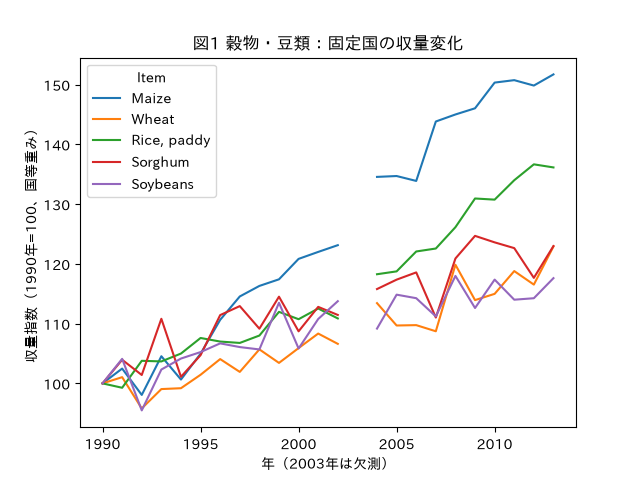

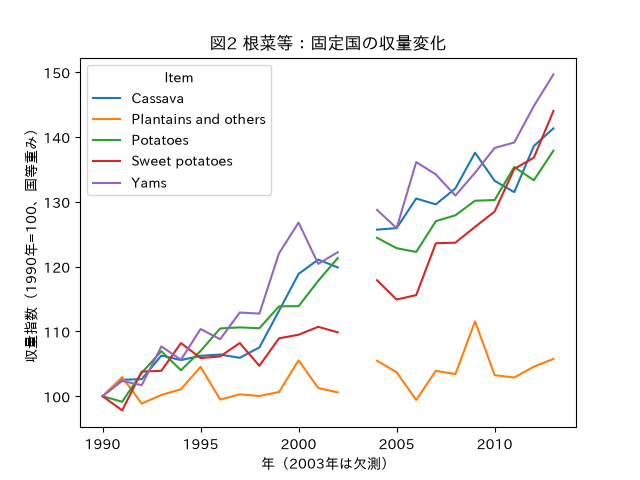

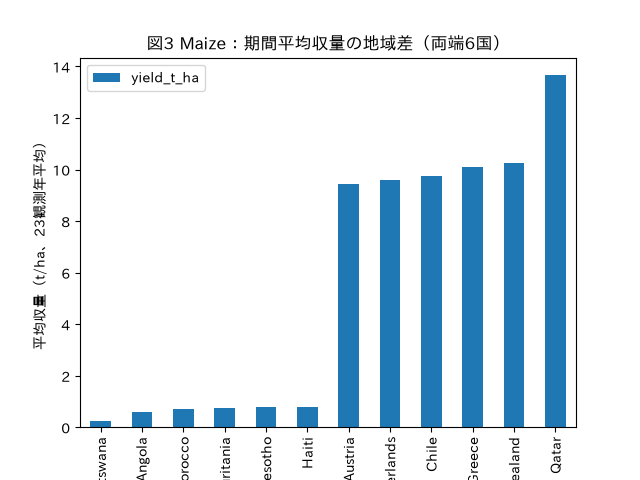

In [7]:
from ai_data_scientist import visualization
from IPython.display import Image
import matplotlib.pyplot as plt
chart_audits = []
def show_chart(frame, kind, x, y, title, xlabel, ylabel, legend):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        png = visualization.render_chart(frame, kind=kind, x=x, y=y, title=title, xlabel=xlabel, ylabel=ylabel)
    glyph_warnings = [str(w.message) for w in caught if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
    if glyph_warnings:
        raise RuntimeError('図の文字欠損を検出: ' + '; '.join(glyph_warnings))
    display(Image(png))
    return {'title': title, 'xlabel': xlabel, 'ylabel': ylabel, 'legend': legend, 'missing_glyphs': [], 'png_bytes': len(png), 'glyph_warning_count': len(glyph_warnings)}
with phase('初回図表作成'):
    grains = ['Maize', 'Wheat', 'Rice, paddy', 'Sorghum', 'Soybeans']
    roots = [c for c in trend_index.columns if c not in grains]
    chart_audits.append(show_chart(trend_index[grains].reset_index(), 'line', 'Year', None, '図1 穀物・豆類：固定国の収量変化', '年（2003年は欠測）', '収量指数（1990年=100、国等重み）', ', '.join(grains)))
    chart_audits.append(show_chart(trend_index[roots].reset_index(), 'line', 'Year', None, '図2 根菜等：固定国の収量変化', '年（2003年は欠測）', '収量指数（1990年=100、国等重み）', ', '.join(roots)))
    maize_regions = crop_means.query("Item == 'Maize'").sort_values('yield_t_ha')
    region_select = pd.concat([maize_regions.head(6), maize_regions.tail(6)]).sort_values('yield_t_ha')
    chart_audits.append(show_chart(region_select, 'bar', 'Area', 'yield_t_ha', '図3 Maize：期間平均収量の地域差（両端6国）', '国・領域（全77国中の抜粋）', '平均収量（t/ha、23観測年平均）', 'Maize'))
    print('図表監査用描画ログ:', json.dumps(chart_audits, ensure_ascii=False, indent=2))


# 反復依頼履歴

## 反復1（原文）
> 2003年が欠落し、完全パネルへの絞り込みで選択バイアスが生じています。同じKaggleデータセットの元表から国・作物・年単位の収量と気象を再構築し、農薬総量との結合が欠落や重複を生む原因か確認してください。元表の欠測・結合脱落を年別に数え、統合表と再構築表で時間変化と地域差がどれほど変わるか比較してください。

選定理由：2003年の全欠落と不要な農薬結合が、時間変化・地域カバレッジの結論を左右し得るため。

In [8]:
iteration_history = []
with phase('反復1・元表再構築と選択バイアス'):
    ysource = reference_yield.query('1990 <= Year <= 2013').copy()
    ysource = ysource.rename(columns={'Value': 'yield_hg'})
    assert set(ysource.Item).issubset(set(raw.Item))
    assert not rainfall.duplicated(['Area', 'Year']).any()
    tsource = temp.query('1990 <= Year <= 2013').copy()
    tstats = tsource.groupby(['Area', 'Year'], as_index=False).agg(temperature=('avg_temp', 'median'), temperature_mean=('avg_temp', 'mean'), temp_n=('avg_temp', 'nunique'), temp_non_null=('avg_temp', 'count'), temp_rows=('avg_temp', 'size'))
    t_unique = tsource.drop_duplicates(['Area', 'Year', 'avg_temp']).groupby(['Area', 'Year'], as_index=False).avg_temp.mean().rename(columns={'avg_temp': 'temperature_unique_mean'})
    tstats = tstats.merge(t_unique, on=['Area', 'Year'], validate='one_to_one')
    psource = frames['pesticides.csv'].rename(columns={'Value': 'pesticides_total'})
    assert not psource.duplicated(['Area', 'Year']).any()
    joined = ysource[key + ['yield_hg']].merge(rainfall, on=['Area', 'Year'], how='left', validate='many_to_one').merge(tstats, on=['Area', 'Year'], how='left', validate='many_to_one').merge(psource[['Area', 'Year', 'pesticides_total']], on=['Area', 'Year'], how='left', validate='many_to_one')
    joined = joined.rename(columns={'average_rain_fall_mm_per_year': 'rainfall'})
    coverage_by_year = joined.groupby('Year').agg(yield_rows=('yield_hg', 'size'), rain_available=('rainfall', 'count'), temp_available=('temperature', 'count'), pesticide_available=('pesticides_total', 'count'))
    coverage_by_year['weather_complete'] = joined.assign(complete=joined[['rainfall', 'temperature']].notna().all(axis=1)).groupby('Year').complete.sum()
    coverage_by_year['original_unique_keys'] = panel.groupby('Year').size().reindex(coverage_by_year.index, fill_value=0)
    weather_clean = cleaning.clean_dataset(joined, operation='drop_na', columns=['rainfall', 'temperature', 'yield_hg'])
    rebuilt = weather_clean.dataframe.copy()
    rebuilt['yield_t_ha'] = rebuilt.yield_hg / 10000
    rebuilt['log_yield'] = np.log(rebuilt.yield_t_ha)
    rebuilt['rain_100'] = rebuilt.rainfall / 100
    assert not rebuilt.duplicated(key).any()
    assert (rebuilt.yield_t_ha > 0).all()
    rebuilt_pair_count = rebuilt.groupby(['Area', 'Item']).Year.nunique()
    rebuilt_keys = rebuilt_pair_count[rebuilt_pair_count == len(years)].reset_index()[['Area', 'Item']]
    final_balanced = rebuilt.merge(rebuilt_keys, on=['Area', 'Item'], validate='many_to_one')
    final_crop_year = final_balanced.groupby(['Item', 'Year']).yield_t_ha.mean().unstack('Item')
    final_country_means = final_balanced.groupby(['Item', 'Area'], as_index=False).agg(yield_t_ha=('yield_t_ha', 'mean'), log_yield=('log_yield', 'mean'), temperature=('temperature', 'mean'), rain_100=('rain_100', 'mean'))
    final_crop_summary = final_country_means.groupby('Item').agg(countries=('Area', 'nunique'), median_t_ha=('yield_t_ha', 'median'), q10_t_ha=('yield_t_ha', lambda s: s.quantile(.1)), q90_t_ha=('yield_t_ha', lambda s: s.quantile(.9)))
    final_crop_summary['change_1990_2013_pct'] = (final_crop_year.loc[2013] / final_crop_year.loc[1990] - 1) * 100
    comparison = crop_summary[['countries', 'change_1990_2013_pct']].join(final_crop_summary[['countries', 'change_1990_2013_pct']], lsuffix='_original', rsuffix='_rebuilt')
    comparison['difference_pp'] = comparison.change_1990_2013_pct_rebuilt - comparison.change_1990_2013_pct_original
    key_overlap = rebuilt.merge(panel[key + ['temperature']], on=key, how='inner', suffixes=('_rebuilt', '_original'), validate='one_to_one')
    print('年別結合カバレッジ:'); print(coverage_by_year.to_string())
    print('再構築の欠測除去:', {'rows_before': weather_clean.rows_before, 'rows_removed': weather_clean.rows_removed, 'rows_after': weather_clean.rows_after})
    print('国:', rebuilt.Area.nunique(), '23観測年完備ペア:', len(rebuilt_keys), '完全パネル行:', len(final_balanced), '元表国:', ysource.Area.nunique())
    print('統合表キーとの重複:', len(key_overlap), '気温中央値最大差:', float((key_overlap.temperature_rebuilt - key_overlap.temperature_original).abs().max()))
    print('元表と統合表の時間変化比較:'); print(comparison.round(4).to_string())
    print('最終地域差表:'); print(final_crop_summary.round(4).to_string())
    iteration1 = {'iteration': 1, 'reason': '欠落年・結合選択の影響', 'weather_complete_rows': len(rebuilt), 'balanced_rows': len(final_balanced), 'balanced_pairs': len(rebuilt_keys), 'countries': rebuilt.Area.nunique(), 'year_2003': coverage_by_year.loc[2003].to_dict(), 'max_change_difference_pp': float(comparison.difference_pp.abs().max()), 'comparison': comparison.reset_index().to_dict('records'), 'remaining_limit': '元表同士の照合は独立データ検証ではない。名称不一致と気象欠測による選択は残る。農薬は主分析から除外。'}
    iteration_history.append(iteration1)
    display(iteration1)


年別結合カバレッジ:
      yield_rows  rain_available  temp_available  pesticide_available  weather_complete  original_unique_keys
Year                                                                                                         
1990         989             767             588                  805               578                   515
1991         987             772             591                  805               581                   515
1992        1066             838             646                  870               639                   564
1993        1075             849             655                  890               643                   568
1994        1079             849             653                  894               641                   566
1995        1085             851             654                  894               642                   567
1996        1083             849             654                  892               642                   567

{'iteration': 1,
 'reason': '欠落年・結合選択の影響',
 'weather_complete_rows': 14868,
 'balanced_rows': 13064,
 'balanced_pairs': 568,
 'countries': 116,
 'year_2003': {'yield_rows': 1094,
  'rain_available': 0,
  'temp_available': 662,
  'pesticide_available': 902,
  'weather_complete': 0,
  'original_unique_keys': 0},
 'max_change_difference_pp': 9.854884021776343,
 'comparison': [{'Item': 'Cassava',
   'countries_original': 40,
   'change_1990_2013_pct_original': 41.31983010182812,
   'countries_rebuilt': 48,
   'change_1990_2013_pct_rebuilt': 35.928414712125026,
   'difference_pp': -5.391415389703091},
  {'Item': 'Maize',
   'countries_original': 77,
   'change_1990_2013_pct_original': 51.703904075975714,
   'countries_rebuilt': 84,
   'change_1990_2013_pct_rebuilt': 51.01369713053434,
   'difference_pp': -0.6902069454413748},
  {'Item': 'Plantains and others',
   'countries_original': 20,
   'change_1990_2013_pct_original': 5.752213002053441,
   'countries_rebuilt': 24,
   'change_1990_2013

# 反復1の結果・証拠・残る限界

年別元表照合から、2003年の全欠落は農薬ではなく降水表に起因すると判明しました（同年の収量1,094行、気温あり662行、農薬あり902行、降水あり0行）。2003年を補完せず、気象を伴う主分析は23観測年を維持します。農薬結合を除くと気象完備14,868行・116地域になり、完備ペアは507から568へ増加。作物別1990–2013変化率は最大9.855ポイント変わりました。セル13の実行出力が証拠です。地域名称不一致・気象欠測による脱落は残り、世界全体には一般化しません。

実行上の訂正：初回の反復1実装は24年完備を仮定して空パネルとなりKeyError(2013)を発生させました。年別カバレッジを確認し、23観測年に修正して再実行しました。これは分析コードの仮定ミスであり、Jupytermind/Kaggle API/CLI/ランナーの不具合とは扱いません。

# 反復依頼履歴：反復2（原文）

> 国間の気温差と国の中の年変動で収量との関連が異なる理由を検証してください。再構築した完全パネルで作物別の国・年固定効果モデルを計算し、気温の中央値と平均値、国別時間トレンドの有無、多重気温のある地域を除く条件で感度分析してください。10作物を同時に調べることによる多重検定も考慮し、安定しない関連を施策効果や気候効果と断定しないでください。

選定理由：初回のSoybeansとYamsの関連だけを選ぶと、気温集計、国別トレンド、10回の検定による不安定な結論になる可能性があるため。

In [9]:
from ai_data_scientist import sensitivity
from statsmodels.stats.multitest import multipletests
import patsy
with phase('反復2・気象モデルの感度と多重検定'):
    assert rebuilt.groupby('Area').rainfall.nunique().max() == 1
    multi_temp_areas = set(tstats.loc[tstats.temp_n > 1, 'Area'])
    final_model_rows = []
    final_fe_models = {}
    for crop, part in final_balanced.groupby('Item'):
        between = final_country_means.query('Item == @crop')
        fit_b = smf.ols('log_yield ~ temperature + rain_100', data=between).fit(cov_type='HC3')
        fit_w = smf.ols('log_yield ~ temperature + C(Area) + C(Year)', data=part).fit(cov_type='cluster', cov_kwds={'groups': part.Area})
        final_fe_models[crop] = fit_w
        for scope, fit, terms in [('between_countries', fit_b, ['temperature', 'rain_100']), ('within_country_year_FE', fit_w, ['temperature'])]:
            for term in terms:
                low, high = fit.conf_int().loc[term]
                final_model_rows.append({'crop': crop, 'scope': scope, 'term': term, 'beta': float(fit.params[term]), 'ci_low': float(low), 'ci_high': float(high), 'p_raw': float(fit.pvalues[term]), 'countries': int(part.Area.nunique()), 'rows': int(fit.nobs)})
    final_models = pd.DataFrame(final_model_rows)
    final_models['p_holm'] = np.nan
    for (scope, term), ids in final_models.groupby(['scope', 'term']).groups.items():
        final_models.loc[ids, 'p_holm'] = multipletests(final_models.loc[ids, 'p_raw'], method='holm')[1]
    def weather_estimate(crop, aggregate='median', country_trend=False, exclude_multi=False):
        part = final_balanced.query('Item == @crop').copy()
        if exclude_multi:
            part = part.loc[~part.Area.isin(multi_temp_areas)]
        if part.Area.nunique() < 8:
            raise ValueError('感度分析に十分な地域クラスタがありません')
        part['t'] = part.temperature if aggregate == 'median' else part.temperature_mean
        part['year_center'] = part.Year - 1990
        nuisance_formula = '1 + C(Area) + C(Year)'
        if country_trend:
            nuisance_formula += ' + C(Area):year_center'
        nuisance = np.asarray(patsy.dmatrix(nuisance_formula, part))
        target = part[['log_yield', 't']].to_numpy()
        # FWL projection: redundant nuisance trends do not identify a new weather slope.
        residual = target - nuisance @ np.linalg.lstsq(nuisance, target, rcond=None)[0]
        denom = float(residual[:, 1] @ residual[:, 1])
        if denom < 1e-10:
            raise ValueError('固定効果除去後の気温変動がなく係数を識別できません')
        return float(residual[:, 1] @ residual[:, 0] / denom)
    weather_plan = sensitivity.SensitivityPlan(parameter_grid={'aggregate': ['median', 'mean'], 'country_trend': [False, True], 'exclude_multi': [False, True]}, max_runs=8)
    weather_sensitivity = {}
    for crop in ['Maize', 'Soybeans', 'Yams']:
        report = sensitivity.run_sensitivity(weather_plan, lambda crop=crop, **kwargs: weather_estimate(crop, **kwargs), stability_tolerance=0.2)
        weather_sensitivity[crop] = asdict(report)
    print('再構築パネルの気象モデル:'); print(final_models.round(5).to_string(index=False))
    print('気温感度分析（20%を事前許容幅として使用; 相対偏差が大きいゼロ近傍は符号と絶対幅も確認）:')
    for crop, report in weather_sensitivity.items():
        print(crop, 'stable=', report['stable'], 'max_relative_deviation=', report['max_relative_deviation'])
        print(pd.DataFrame([dict(r['specification'], beta=r['value']) for r in report['results']]).round(5).to_string(index=False))
    within_final = final_models.query("scope == 'within_country_year_FE'")
    iteration2 = {'iteration': 2, 'reason': '気温集計・国別トレンド・多重検定', 'holm_significant_within_crops': within_final.loc[within_final.p_holm < .05, 'crop'].tolist(), 'weather_sensitivity': weather_sensitivity, 'remaining_limit': '10作物内でHolm補正。3感度対象は初回で注目した探索的選択。95%区間は無補正。地点不明の気温と栽培期不明、灌漑・品種・土地・技術など未観測交絡が残る。'}
    iteration_history.append(iteration2)
    display({'iteration': 2, 'holm_significant_within_crops': iteration2['holm_significant_within_crops'], 'sensitivity_status': {c: {'stable': r['stable'], 'max_relative_deviation': r['max_relative_deviation'], 'beta_min': min(v['value'] for v in r['results']), 'beta_max': max(v['value'] for v in r['results'])} for c, r in weather_sensitivity.items()}, 'remaining_limit': iteration2['remaining_limit']})


再構築パネルの気象モデル:
                crop                  scope        term     beta   ci_low  ci_high   p_raw  countries  rows  p_holm
             Cassava      between_countries temperature  0.01616 -0.04529  0.07761 0.60627         48    48 0.82903
             Cassava      between_countries    rain_100  0.00295 -0.02085  0.02676 0.80786         48    48 1.00000
             Cassava within_country_year_FE temperature  0.02813 -0.06227  0.11853 0.54198         48  1104 1.00000
               Maize      between_countries temperature -0.07895 -0.10420 -0.05369 0.00000         84    84 0.00000
               Maize      between_countries    rain_100  0.01374 -0.01011  0.03759 0.25878         84    84 1.00000
               Maize within_country_year_FE temperature -0.02468 -0.06693  0.01757 0.25220         84  1932 1.00000
Plantains and others      between_countries temperature -0.05537 -0.12395  0.01321 0.11355         24    24 0.34065
Plantains and others      between_countries    rain_100  0

{'iteration': 2,
 'holm_significant_within_crops': [],
 'sensitivity_status': {'Maize': {'stable': False,
   'max_relative_deviation': 1.4413606162935308,
   'beta_min': -0.06025639916092038,
   'beta_max': -0.02468148243187503},
  'Soybeans': {'stable': False,
   'max_relative_deviation': 0.4019001025115017,
   'beta_min': -0.08960884395811172,
   'beta_max': -0.06141292336533429},
  'Yams': {'stable': False,
   'max_relative_deviation': 0.5499066408676393,
   'beta_min': 0.04938244346807955,
   'beta_max': 0.1283400756515036}},
 'remaining_limit': '10作物内でHolm補正。3感度対象は初回で注目した探索的選択。95%区間は無補正。地点不明の気温と栽培期不明、灌漑・品種・土地・技術など未観測交絡が残る。'}

# 反復2の結果・証拠・残る限界

再構築パネルでは国間の高気温と低収量の関連が複数作物に見られますが、国・年固定効果で時間変動を取り出すと10作物のHolm補正後はいずれも5%水準を下回りません。これは「気温の影響がない」という証明ではありません。8仕様の感度分析ではMaize・Soybeans・Yamsの係数の方向は維持するものの、20%の量的安定性基準はいずれも不合格（最大相対偏差1.441、0.402、0.550）。セル16の係数表と感度表が証拠です。期間平均の関連から年々の暑さや施策の効果を導くことはできません。

モデル実装上の訂正：国別傾きと年ダミーを同時に直接回帰すると、共通傾きが重複してnuisance列にrank deficiency警告が出ました。Frisch–Waugh–Lovellの直交射影で従属変数・気温からnuisance空間を除き、気温残差の分散を確認して係数を計算しました。これは分析設計上の冗長性で、Jupytermindの問題ではありません。

# 反復依頼履歴：反復3（原文）

> 1990年と2013年だけの比較に結果が依存していないか確認してください。前後3年平均との比較、国平均と国中央値、気象が完備した固定国と収量だけが24年完備した固定国の違いを検証し、2003年も収量元表から使える場合は時間図に示してください。地域差についても、同じ作物の10–90パーセンタイルと、期間の前半・後半で地域順位がどの程度維持されるかを確認してください。

選定理由：端点の異常年、国構成、平均を支配する高収量国が「収量増加」の結論を実質的に変える可能性があるため。

In [10]:
from scipy.stats import spearmanr
with phase('反復3・時間変化と地域差の安定性'):
    temporal = ysource[key + ['yield_hg']].copy()
    temporal['yield_t_ha'] = temporal.yield_hg / 10000
    temporal_counts = temporal.groupby(['Area', 'Item']).Year.nunique()
    temporal_keys = temporal_counts[temporal_counts == 24].reset_index()[['Area', 'Item']]
    yield_complete = temporal.merge(temporal_keys, on=['Area', 'Item'], validate='many_to_one')
    weather_temporal = yield_complete.merge(rebuilt_keys, on=['Area', 'Item'], validate='many_to_one')
    def temporal_change(crop, window=1, aggregation='arithmetic', country_set='weather_complete'):
        population = weather_temporal if country_set == 'weather_complete' else yield_complete
        part = population.query('Item == @crop')
        early = part.loc[part.Year.between(1990, 1990+window-1)].groupby('Area').yield_t_ha.mean()
        late = part.loc[part.Year.between(2014-window, 2013)].groupby('Area').yield_t_ha.mean()
        assert early.index.equals(late.index)
        start = early.mean() if aggregation == 'arithmetic' else early.median()
        end = late.mean() if aggregation == 'arithmetic' else late.median()
        if start <= 0:
            raise ValueError('初期収量が正でなく変化率を定義できません')
        return float((end/start-1)*100)
    temporal_plan = sensitivity.SensitivityPlan(parameter_grid={'window': [1, 3], 'aggregation': ['arithmetic', 'median'], 'country_set': ['weather_complete', 'yield_complete']}, max_runs=8)
    temporal_sensitivity = {}
    temporal_summary_rows = []
    regional_rank_rows = []
    for crop in sorted(raw.Item.unique()):
        report = sensitivity.run_sensitivity(temporal_plan, lambda crop=crop, **kwargs: temporal_change(crop, **kwargs), stability_tolerance=0.2)
        temporal_sensitivity[crop] = asdict(report)
        vals = [r.value for r in report.results]
        part = weather_temporal.query('Item == @crop')
        region_means = part.groupby('Area').yield_t_ha.mean()
        early_rank = part.loc[part.Year <= 2001].groupby('Area').yield_t_ha.mean()
        late_rank = part.loc[part.Year >= 2002].groupby('Area').yield_t_ha.mean()
        rho = float(spearmanr(early_rank, late_rank).statistic)
        regional_rank_rows.append({'crop': crop, 'countries': len(region_means), 'q10_t_ha': region_means.quantile(.1), 'median_t_ha': region_means.median(), 'q90_t_ha': region_means.quantile(.9), 'q90_q10_ratio': region_means.quantile(.9)/region_means.quantile(.1), 'early_late_rank_rho': rho})
        temporal_summary_rows.append({'crop': crop, 'baseline_change_pct': report.baseline_value, 'min_change_pct': min(vals), 'max_change_pct': max(vals), 'all_positive': all(v > 0 for v in vals), 'stable_20pct': report.stable, 'max_relative_deviation': report.max_relative_deviation, 'weather_countries': int(part.Area.nunique()), 'yield_only_countries': int(yield_complete.query('Item == @crop').Area.nunique())})
    temporal_summary = pd.DataFrame(temporal_summary_rows)
    regional_stability = pd.DataFrame(regional_rank_rows)
    full_time_means = weather_temporal.groupby(['Item', 'Year']).yield_t_ha.mean().unstack('Item')
    full_time_index = full_time_means.div(full_time_means.loc[1990]).mul(100)
    print('端点・3年窓・平均/中央値・国集合の8仕様:'); print(temporal_summary.round(4).to_string(index=False))
    print('地域差と前半/後半の地域順位:'); print(regional_stability.round(4).to_string(index=False))
    print('2003年収量観測は使用可能:', int((weather_temporal.Year == 2003).sum()), '気象未完備のまま。補完はしない。')
    print('時間分析の収量ゼロ行:', int((yield_complete.yield_t_ha == 0).sum()), '負値:', int((yield_complete.yield_t_ha < 0).sum()))
    iteration3 = {'iteration': 3, 'reason': '端点・国集合・集計の頑健性と地域順位', 'temporal_summary': temporal_summary.to_dict('records'), 'regional_stability': regional_stability.to_dict('records'), 'year_2003_yield_rows': int((weather_temporal.Year == 2003).sum()), 'all_crops_positive_every_specification': bool(temporal_summary.all_positive.all()), 'remaining_limit': '収量のみの24年完備国でも世界を代表しない。国中央値の変化は個々の国の変化率中央値ではない。8仕様は妥当な範囲の探索であり全仕様を保証しない。'}
    iteration_history.append(iteration3)
    display({'iteration': 3, 'all_crops_positive_every_specification': iteration3['all_crops_positive_every_specification'], 'stable_crops': temporal_summary.loc[temporal_summary.stable_20pct, 'crop'].tolist(), 'remaining_limit': iteration3['remaining_limit']})


端点・3年窓・平均/中央値・国集合の8仕様:
                crop  baseline_change_pct  min_change_pct  max_change_pct  all_positive  stable_20pct  max_relative_deviation  weather_countries  yield_only_countries
             Cassava              35.9284         16.1330         35.9284          True         False                  0.5510                 48                   100
               Maize              51.0137         50.0321         67.1415          True         False                  0.3161                 84                   136
Plantains and others               4.9647          2.7154         42.8962          True         False                  7.6403                 24                    47
            Potatoes              35.7239         27.8726         36.8167          True         False                  0.2198                 84                   127
         Rice, paddy              33.8095         28.2922         54.1170          True         False                  0.6006                 

{'iteration': 3,
 'all_crops_positive_every_specification': True,
 'stable_crops': [],
 'remaining_limit': '収量のみの24年完備国でも世界を代表しない。国中央値の変化は個々の国の変化率中央値ではない。8仕様は妥当な範囲の探索であり全仕様を保証しない。'}

# 反復3の結果・証拠・残る限界

8仕様では全10作物の変化率が正で、増加の方向は維持しました。ただし増加幅の20%安定性基準を満たす作物はありません。例えばMaizeは50.032–67.142%、Wheatは22.356–46.415%、Plantains and othersは2.715–42.896%と、国集合・代表値によって大きく変わります。地域平均収量の10–90パーセンタイル比は2.652–8.717倍、前半/後半の順位相関は0.824–0.959。セル19の8仕様要約・地域順位表が証拠です。

反復終了理由：3回の上限に到達しました。残る実質的な限界は独立参照データ、栽培期・地点・面積重み、灌漑・品種・施策の識別情報の不在で、同じ表の追加分割のみでは解消できません。安定した「世界の増加幅」や「施策効果」の主張は撤回し、収録固定国の記述として終了します。

# 最終図表

図4・5：同じ国作物ペアの1990–2013収量指数（2003年も元収量表で観測済み、気象値を補完したものではない）。図6：同じ作物内の国別24年平均収量の分布。図7：気温の国間関連と国・年固定効果関連の比較（95%区間は多重補正なし、判断にはHolm p値も利用）。図8：Sorghumの国間降水量と期間平均収量。降水量の年変動や施策効果の図ではありません。

最終図表監査ログ: [
  {
    "title": "図4 穀物・豆類：固定国の時間変化（最終）",
    "xlabel": "年（収量は2003年も観測）",
    "ylabel": "収量指数（1990年=100、国等重み）",
    "legend": "Maize, Wheat, Rice, paddy, Sorghum, Soybeans",
    "missing_glyphs": [],
    "png_bytes": 72127,
    "glyph_warning_count": 0
  },
  {
    "title": "図5 根菜等：固定国の時間変化（最終）",
    "xlabel": "年（収量は2003年も観測）",
    "ylabel": "収量指数（1990年=100、国等重み）",
    "legend": "Cassava, Plantains and others, Potatoes, Sweet potatoes, Yams",
    "missing_glyphs": [],
    "png_bytes": 72461,
    "glyph_warning_count": 0
  },
  {
    "title": "図6 作物ごとの地域差：国別24年平均収量",
    "xlabel": "収量（t/ha、国等重み）",
    "ylabel": "作物（作物間の水分等の違いに注意）",
    "legend": "国分布10–90%; 国中央値",
    "missing_glyphs": [],
    "png_bytes": 58572,
    "glyph_warning_count": 0
  },
  {
    "title": "図7 気温との関連：国間と国内年変動を分離",
    "xlabel": "log収量の係数（avg_temp数値1の差、単位は推定）",
    "ylabel": "作物（横線は無補正95%区間）",
    "legend": "国間; 国内年変動",
    "missing_glyphs": [],
    "png_bytes": 73490,
    "glyph_warning_count": 0
  },

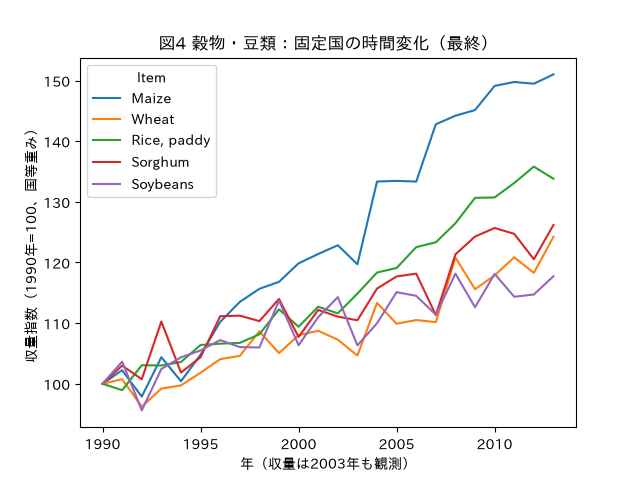

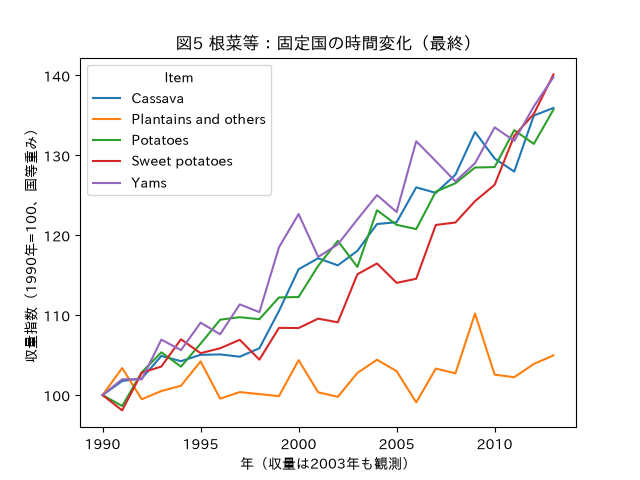

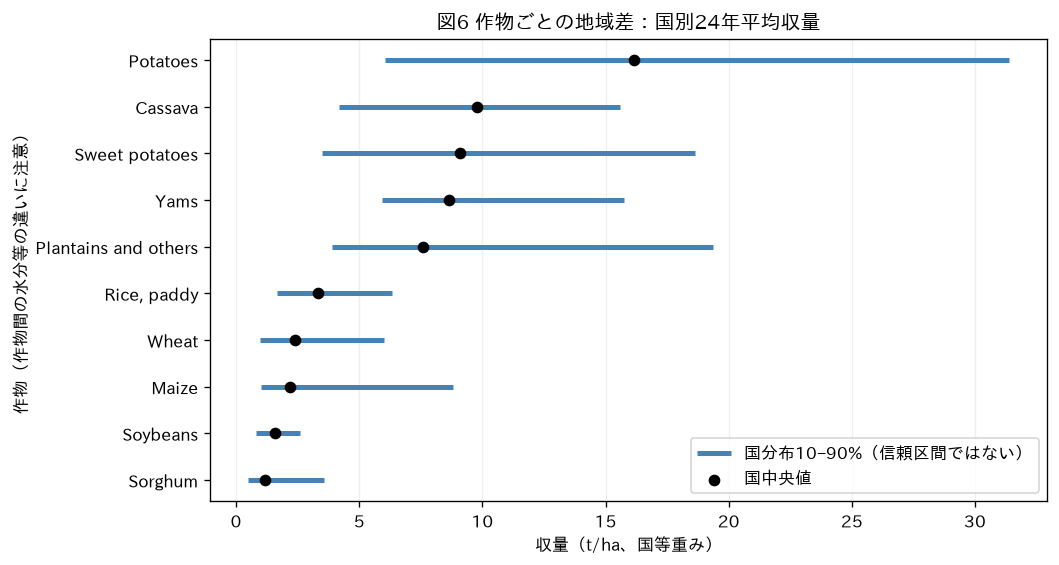

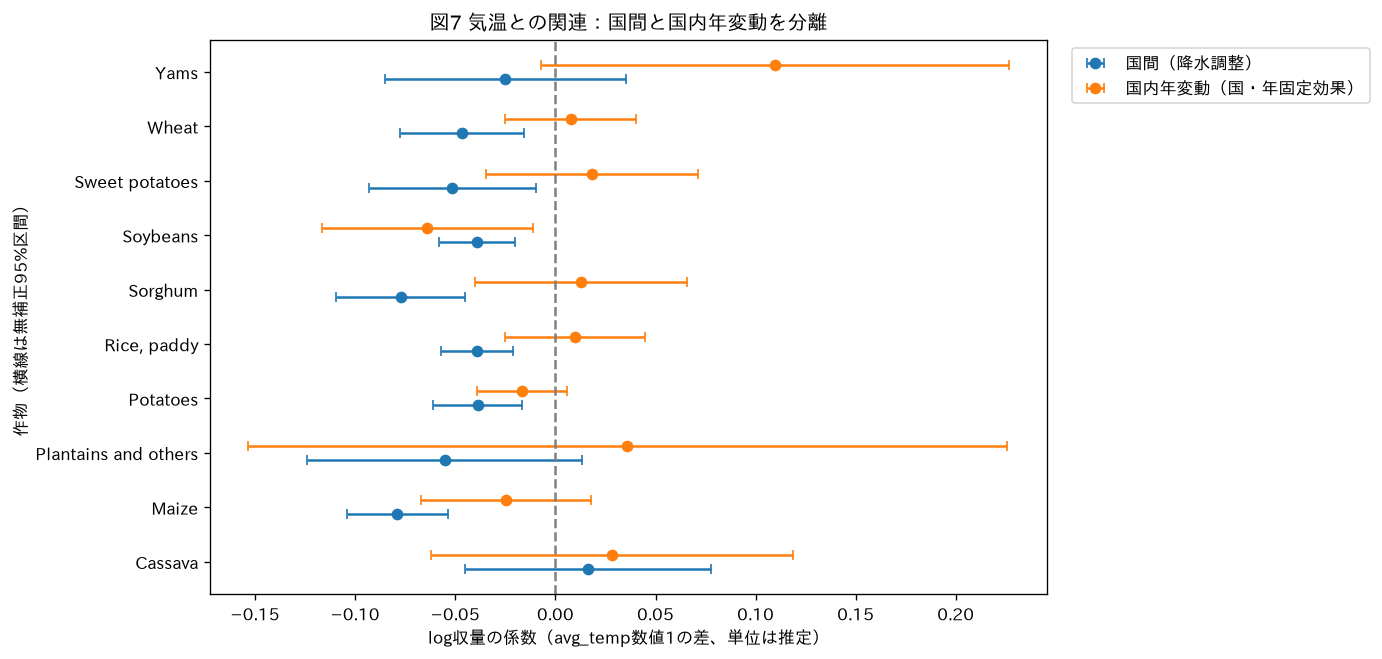

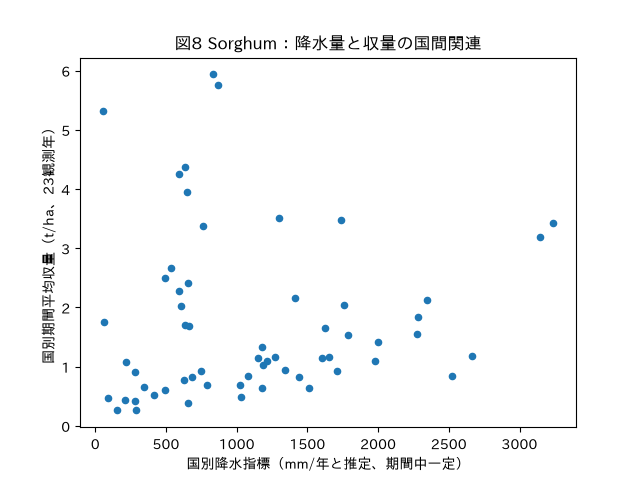

In [11]:
final_chart_audits = []
def show_custom_chart(fig, title, xlabel, ylabel, legend):
    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            buf = io.BytesIO()
            fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
        missing = [str(w.message) for w in caught if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
        if missing:
            raise RuntimeError('図の文字欠損: ' + '; '.join(missing))
        payload = buf.getvalue()
        display(Image(payload))
        return {'title': title, 'xlabel': xlabel, 'ylabel': ylabel, 'legend': legend, 'missing_glyphs': [], 'png_bytes': len(payload), 'glyph_warning_count': len(missing)}
    finally:
        plt.close(fig)
with phase('最終図表作成・文字欠損検査'):
    final_chart_audits.append(show_chart(full_time_index[grains].reset_index(), 'line', 'Year', None, '図4 穀物・豆類：固定国の時間変化（最終）', '年（収量は2003年も観測）', '収量指数（1990年=100、国等重み）', ', '.join(grains)))
    final_chart_audits.append(show_chart(full_time_index[roots].reset_index(), 'line', 'Year', None, '図5 根菜等：固定国の時間変化（最終）', '年（収量は2003年も観測）', '収量指数（1990年=100、国等重み）', ', '.join(roots)))
    r = regional_stability.sort_values('median_t_ha')
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hlines(r.crop, r.q10_t_ha, r.q90_t_ha, color='steelblue', linewidth=3, label='国分布10–90%（信頼区間ではない）')
    ax.scatter(r.median_t_ha, r.crop, color='black', label='国中央値', zorder=3)
    title = '図6 作物ごとの地域差：国別24年平均収量'
    ax.set(title=title, xlabel='収量（t/ha、国等重み）', ylabel='作物（作物間の水分等の違いに注意）')
    ax.legend(loc='lower right')
    ax.grid(axis='x', alpha=.2)
    final_chart_audits.append(show_custom_chart(fig, title, ax.get_xlabel(), ax.get_ylabel(), '国分布10–90%; 国中央値'))
    fig, ax = plt.subplots(figsize=(9, 6))
    crop_order = sorted(raw.Item.unique())
    for scope, offset, color, label in [('between_countries', -.13, 'tab:blue', '国間（降水調整）'), ('within_country_year_FE', .13, 'tab:orange', '国内年変動（国・年固定効果）')]:
        m = final_models.query('scope == @scope and term == "temperature"').set_index('crop').loc[crop_order]
        pos = np.arange(len(crop_order)) + offset
        ax.errorbar(m.beta, pos, xerr=np.vstack([m.beta-m.ci_low, m.ci_high-m.beta]), fmt='o', color=color, label=label, capsize=3)
    ax.set_yticks(np.arange(len(crop_order)), crop_order)
    ax.axvline(0, color='grey', linestyle='--')
    title = '図7 気温との関連：国間と国内年変動を分離'
    ax.set(title=title, xlabel='log収量の係数（avg_temp数値1の差、単位は推定）', ylabel='作物（横線は無補正95%区間）')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    final_chart_audits.append(show_custom_chart(fig, title, ax.get_xlabel(), ax.get_ylabel(), '国間; 国内年変動'))
    sorghum_regions = final_country_means.query("Item == 'Sorghum'").copy()
    sorghum_regions['rainfall_mm'] = sorghum_regions.rain_100 * 100
    final_chart_audits.append(show_chart(sorghum_regions, 'scatter', 'rainfall_mm', 'yield_t_ha', '図8 Sorghum：降水量と収量の国間関連', '国別降水指標（mm/年と推定、期間中一定）', '国別期間平均収量（t/ha、23観測年）', '各点=国（60地域）、年変動ではない'))
    print('最終図表監査ログ:', json.dumps(final_chart_audits, ensure_ascii=False, indent=2))


# 最終manifest・日本語結論の証拠

初回の統合表から元表へ分析母集団を更新したため、最終のデータ定義・前提を別途記録します。時間・地域の24年パネルと気象の23年パネルを混同しません。

In [12]:
from ai_data_scientist import insight_engine, notebook_audit
import platform
with phase('最終manifestと結論の証拠作成'):
    rebuilt_anomalies = data_quality.detect_anomalies(rebuilt, {'yield_hg': {'min': 0, 'not_null': True}, 'Year': {'min': 1990, 'max': 2013, 'not_null': True}, 'rainfall': {'min': 0, 'max': 12000, 'not_null': True}, 'temperature': {'min': -60, 'max': 60, 'not_null': True}, 'Area': {'not_null': True}, 'Item': {'not_null': True}})
    if rebuilt_anomalies:
        raise ValueError('再構築パネルに未解決の意味的異常あり')
    final_definition_manifest = data_definition.build_manifest(
        source=definition_manifest.source,
        dataset_scope={**definition_manifest.dataset_scope, 'final_geography': F({'weather_available_areas': int(rebuilt.Area.nunique()), 'yield_source_areas': int(ysource.Area.nunique())}, 'verified', '元表再構築の実行結果'), 'final_keys': F({'weather': '国×作物×年;23観測年完備568ペア', 'temporal': '同じ568ペアの収量24年'}, 'verified', '国作物キー重複なしと各年観測数検査')},
        variables=definition_manifest.variables,
        transformations=definition_manifest.transformations + ('元4表から国作物年へ再構築', '気温は元表国年中央値; 平均との感度比較', '農薬結合を必須条件から除外', '気象は2003年を除く23観測年; 時間図の収量のみ24年', '名称の曖昧な国対応の推測置換は行わない'))
    A = analysis_assumptions.Assumption
    final_assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'weather': '気象完備14,868行; 主回帰23年完備13,064行', 'time_and_region': '気象完備国作物568ペアの元収量24年; 気象補完なし', 'aggregation': '国等重み、面積・生産量重み不明', 'inference': '探索的関連; 国内は国クラスタ誤差、国間はHC3; 各scope×変数で10作物Holm補正'}, causal_scope='associational',
        assumptions=(A('yield-unit-key', 'hg/ha単位と同一キー収量を元表で確認', 'verified', evidence_cell=get_ipython().execution_count, conclusion_critical=True), A('fixed-population', '時間比較の国集合固定と端点/3年窓/平均/中央値/国集合感度を実施', 'tested', evidence_cell=get_ipython().execution_count, conclusion_critical=True), A('temperature-proxy', '地点不明の中央値気温が作付け地と栽培期の気温を代表する', 'assumed', impact_if_false='気象係数の測定誤差と解釈制約', conclusion_critical=True), A('external-validity', '収録固定国が世界全体を代表する', 'rejected', impact_if_false='世界平均・施策に一般化不可', conclusion_critical=True), A('policy-identification', '国差・時間差から施策効果を識別できる', 'rejected', impact_if_false='因果・施策結論は適用不可', conclusion_critical=True)))
    final_assumption_findings = analysis_assumptions.check_manifest(final_assumptions)
    final_unknown = [(p, asdict(v)) for p, v in final_definition_manifest.unresolved_fields()]
    semantic_caveats = []
    for section_name in ['source', 'dataset_scope']:
        for name, value in getattr(final_definition_manifest, section_name).items():
            if isinstance(value, data_definition.FieldValue) and value.status in ['unknown', 'inferred']:
                semantic_caveats.append({'field': section_name + '.' + name, **asdict(value)})
    for name, fields in final_definition_manifest.variables.items():
        for field, value in fields.items():
            if value.status in ['unknown', 'inferred']:
                semantic_caveats.append({'field': 'variables.'+name+'.'+field, **asdict(value)})
    # In-memory reproduction: the current auditor does not flag absent chart metadata.
    on_disk = nbformat.read(handle.notebook_path, as_version=4)
    visual_sample = next(c for c in on_disk.cells if c.cell_type == 'code' and any('image/png' in o.get('data', {}) for o in c.get('outputs', [])))
    repro = nbformat.v4.new_notebook(cells=[nbformat.from_dict(json.loads(json.dumps(visual_sample)))])
    repro.cells[0].metadata = {}
    metadata_gap_findings = notebook_audit.audit_visual_outputs(repro, (0,))
    improvement_evidence = {'classification': 'Jupytermind図表監査の検査漏れ（機能不足）', 'test': 'PNG付き実行済みセルのmetadataを空にしてaudit_visual_outputsへ渡す', 'expected': 'missing_glyphs・title・xlabel・ylabel・legend情報の欠如を監査所見として報告', 'actual_findings_count': len(metadata_gap_findings), 'actual_findings': [asdict(f) for f in metadata_gap_findings], 'impact': 'visual_audit=Trueでもメタデータが全くない図を見逃す。画素自体の目視検査ではない', 'workaround': '各図の描画時警告を検査し、必須メタデータと個別render_auditをenqueue_writeで付与。図も目視で確認', 'related_cells': ['初回図表セル11', '最終図表セル22', '再現・証拠セル24', '最終監査セル（metadata.role=audit）'], 'separation': 'メモリ内の純粋なJupytermind関数で再現し、Kaggle認証・CLI・ベンチマークランナーを介さない'}
    mae = temporal_summary.set_index('crop').loc['Maize']
    wheat = temporal_summary.set_index('crop').loc['Wheat']
    rice = temporal_summary.set_index('crop').loc['Rice, paddy']
    maize_reg = regional_stability.set_index('crop').loc['Maize']
    n_sig = len(iteration2['holm_significant_within_crops'])
    evidence_tokens = {'time': f"FINAL_TIME_MAIZE_PCT={mae.baseline_change_pct:.6f}", 'region': f"FINAL_REGION_MAIZE_RATIO={maize_reg.q90_q10_ratio:.6f}", 'weather': f'FINAL_WEATHER_HOLM_SIGNIFICANT={n_sig}'}
    conclusion_texts = {
      'time': f"""# 日本語結論：時間変化

同じ地域集合で比較した1990–2013年の国平均収量は、トウモロコシ(Maize)で{mae.baseline_change_pct:.2f}%、小麦(Wheat)で{wheat.baseline_change_pct:.2f}%、籾米(Rice, paddy)で{rice.baseline_change_pct:.2f}%増加しました。3年窓・平均/中央値・収量のみ完備国への変更を含む8仕様では全10作物で増加方向が共通でした。ただしトウモロコシの増加幅は{mae.min_change_pct:.2f}–{mae.max_change_pct:.2f}%など、国集合と代表値に依存し、全作物で20%の量的安定性基準は未達です。これは収録固定国の記述で、世界の面積加重収量や政策成果ではありません。""",
      'region': f"""# 日本語結論：作物差・地域差

同じ作物でも地域差は大きく、トウモロコシの国別24年平均収量の10–90パーセンタイルは{maize_reg.q10_t_ha:.3f}–{maize_reg.q90_t_ha:.3f} t/ha（約{maize_reg.q90_q10_ratio:.2f}倍）です。前半/後半の地域順位相関は同作物で{maize_reg.early_late_rank_rho:.3f}であり、持続的な国差が観察されます。根菜等の質量収量は穀物より大きい傾向ですが、水分・可食部などの定義が揃わないため、作物間のt/haを栄養・利益・生産性の優劣として比較しません。地域差を施策・農薬・気象単独の効果と解釈しません。""",
      'weather': f"""# 日本語結論：気象・施策の解釈限界

国間の高気温と低収量の関連は複数作物で見られる一方、国・年固定効果で分けた国内年変動の気温係数は、10作物Holm補正後の5%水準で該当{n_sig}作物でした。非有意は『効果なし』の証明ではなく、感度分析の係数幅も不安定です。降水量は国別に全期間一定で、年々の降雨変化の関連はこの表では推定できません。気温単位は摂氏と推定されるだけで、観測地点・栽培期・農地重みは不明です。灌漑、品種、技術、土地条件、施策導入の交絡を解消していない観察データなので、施策効果や温暖化の因果効果を断定しません。"""}
    evidence_bundle = {'run_id': run_id, 'evidence_tokens': evidence_tokens, 'QC': QC, 'provenance': provenance, 'temporal_summary': temporal_summary.to_dict('records'), 'regional_stability': regional_stability.to_dict('records'), 'weather_models': final_models.to_dict('records'), 'weather_sensitivity': weather_sensitivity, 'iteration_history': list({r['iteration']: r for r in iteration_history}.values()), 'definition_manifest': asdict(final_definition_manifest), 'assumption_manifest': asdict(final_assumptions), 'assumption_findings': [asdict(f) for f in final_assumption_findings], 'semantic_caveats': semantic_caveats, 'rebuilt_anomalies': [asdict(a) for a in rebuilt_anomalies], 'improvement_evidence': improvement_evidence}
    (data_dir / 'analysis-evidence.json').write_text(json.dumps(evidence_bundle, ensure_ascii=False, indent=2))
    print('最終分析前提警告（全件）:', json.dumps(evidence_bundle['assumption_findings'], ensure_ascii=False, indent=2))
    print('unknown/inferred定義（全件）:', json.dumps(semantic_caveats, ensure_ascii=False, indent=2))
    print('改善候補再現:', json.dumps(improvement_evidence, ensure_ascii=False, indent=2))
    print('再現環境:', {'Python': platform.python_version(), 'pandas': pd.__version__, 'numpy': np.__version__})
    for text in conclusion_texts.values():
        print(text)
    display({'evidence_tokens': evidence_tokens, 'temporal_summary': temporal_summary.to_dict('records'), 'regional_stability': regional_stability.to_dict('records'), 'within_weather_models': within_final.to_dict('records'), 'assumption_findings': evidence_bundle['assumption_findings']})


最終分析前提警告（全件）: [
  {
    "code": "unresolved_conclusion_critical_assumption",
    "severity": "warning",
    "message": "Conclusion-critical assumption 'temperature-proxy' has status 'assumed', not verified/tested.",
    "assumption_id": "temperature-proxy"
  },
  {
    "code": "unresolved_conclusion_critical_assumption",
    "severity": "warning",
    "message": "Conclusion-critical assumption 'external-validity' has status 'rejected', not verified/tested.",
    "assumption_id": "external-validity"
  },
  {
    "code": "unresolved_conclusion_critical_assumption",
    "severity": "warning",
    "message": "Conclusion-critical assumption 'policy-identification' has status 'rejected', not verified/tested.",
    "assumption_id": "policy-identification"
  }
]
unknown/inferred定義（全件）: [
  {
    "field": "source.measurement_process",
    "value": null,
    "status": "unknown",
    "source": "詳細な出典系列ID・取得手順なし"
  },
  {
    "field": "dataset_scope.geography",
    "value": "国・領域名。県・圃場・観測地点IDなし",


{'evidence_tokens': {'time': 'FINAL_TIME_MAIZE_PCT=51.013697',
  'region': 'FINAL_REGION_MAIZE_RATIO=8.716983',
  'weather': 'FINAL_WEATHER_HOLM_SIGNIFICANT=0'},
 'temporal_summary': [{'crop': 'Cassava',
   'baseline_change_pct': 35.928414712125026,
   'min_change_pct': 16.13303474155674,
   'max_change_pct': 35.928414712125026,
   'all_positive': True,
   'stable_20pct': False,
   'max_relative_deviation': 0.5509672533335513,
   'weather_countries': 48,
   'yield_only_countries': 100},
  {'crop': 'Maize',
   'baseline_change_pct': 51.01369713053432,
   'min_change_pct': 50.0321459288378,
   'max_change_pct': 67.1415171766913,
   'all_positive': True,
   'stable_20pct': False,
   'max_relative_deviation': 0.3161468576741059,
   'weather_countries': 84,
   'yield_only_countries': 136},
  {'crop': 'Plantains and others',
   'baseline_change_pct': 4.964674965246263,
   'min_change_pct': 2.715377038977995,
   'max_change_pct': 42.89624199735182,
   'all_positive': True,
   'stable_20pct': 

# 使用したJupytermindモジュール

以下はこのNotebookで直接importし、直接呼び出した `ai_data_scientist` モジュールのみです。間接利用は数えません。Kaggle SDK・pandas・numpy・statsmodels・patsy・scipy・matplotlib・IPython・nbformatは外部依存でありJupytermind利用には含めません。

| モジュール | 直接呼び出した関数・クラス | 使用目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 指定slug、保存先固定、データ格納とNotebook直列書込み |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | run_id v020-exp-46の実行/書込み/終状態追跡 |
| language_router | detect_language | 日本語依頼の検出 |
| ingestion | SourceSpec, ingest | 取得済みCSV読込み、打切りなし確認 |
| cleaning | clean_dataset | 完全重複と必須気象欠測の除去件数記録 |
| eda | explore | dtype・欠測・カテゴリ・記述統計 |
| data_quality | detect_anomalies | 非負・必須項目・妥当な値域の意味的検査 |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 単位、粒度、出典、確信度と未解決定義 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 集計・母集団・因果範囲と未解決前提 |
| stats_analysis | correlation | 混合単純相関の診断（最終結論には不採用） |
| sensitivity | SensitivityPlan, run_sensitivity | 気温3作物各8仕様、時間10作物各8仕様、20%量的安定性 |
| visualization | render_chart | PNG図表、同梱日本語フォント対応の描画 |
| insight_engine | extract_cited_value, record_insight | 実行出力から根拠トークンを抽出し日本語結論にevidence付与 |
| notebook_audit | audit_notebook, audit_visual_outputs | visual_audit=Trueの最終監査とメタデータ欠落検査の再現 |

# Jupytermind改善候補

分類：図表監査の検査漏れ／機能不足。

再現条件：実行済みPNG出力を持つセルのmetadataを空にしたメモリ内Notebookを `notebook_audit.audit_visual_outputs(..., (0,))` に渡す（証拠セル24）。

期待する挙動：文字欠損の検査情報、タイトル、軸ラベル、凡例メタデータの欠如を報告する。実際の挙動：空タプルが返り、所見0件。画像はあるがメタデータ全欠如を見逃す。

影響：visual_audit=Trueの結果だけで文字・ラベル検査の実施を保証できない。PNG byte-densityは実画素・文字の正確な監査ではない。

回避策：描画時のGlyph警告を捕捉してエラーにし、各図のtitle/xlabel/ylabel/legend/missing_glyphsと個別描画ログをenqueue_writeで明示記録。最終図7では凡例がデータを隠さないよう欄外へ移動。全図を目視確認し、最終監査で必須metadataも別途assertする。

関係するセルとログ：図表セル11・22、再現セル24の「改善候補再現」出力、data/analysis-evidence.json のimprovement_evidence、最終監査セルのmetadata検査とvisual_findings。

切り分け：この再現はメモリ内のJupytermind関数だけで行い、Copilot CLI、Kaggle API、ベンチマークランナーの通信・認証・スケジューリングは介さない。これら外部系の不具合は観測していません。分析コードの24年仮定、f-string改行、冗長nuisance列は分析実装側の訂正であり改善候補に含めません。

# 適用不可・未解決定義・分析の限界

独立参照とのvalidate_anomalies・dataset_validation.compare_datasetsは未適用：第2の独立データが提供されておらず、同じslugの元表は独立検証ではないため。元収量との完全キー一致を内部整合性チェックとして行いました。

mcp_gateway.run_and_recordは未適用：ホスト側Jupyter MCPツールは使用できる一方、カーネルから呼べるMCPClientオブジェクトは提供されていません。偽clientやeval、セルから自分のカーネルを再実行する再帰呼出しは使わず、Jupyter MCP execute_cellで実行し、enqueue_writeで管理書込みを直列化しています。モジュールを使用済みとは数えません。

statistical z-scoreによる外れ値除去は未適用：作物・国の本来の収量差を一律外れ値とすると比較対象を失うため。負値・非有限値・非数値降水・重複キー・同一国年の多重気温・国別定数降水・年カバレッジを検査しました。妥当範囲は異常候補の検出用で、気象の測定品質を保証しません。

降水の時間効果推定は適用不可：期間中で国別定数のため国固定効果と識別不能。気温の単位（推定）、空間重み・栽培期（不明）、地域粒度（国/領域と推定）、観測・集計経路（不明）、水分・可食部の比較可能性（未確認）が残ります。栽培面積・生産量がないため面積加重の世界平均は推定しません。農薬は国総量であり、ha当たり施用量や施策の割当ではありません。施策・気候因果効果の識別分析は適用不可です。

前提manifestの全警告は証拠セル24に記録：気温代表性はassumed、世界への外的妥当性と施策識別はrejected。結果の非有意を無効果の証明に使いません。取引・採用・政策判断への直接の因果的勧告はしません。

反復1〜3の原文・選定理由は反復依頼履歴、結果・証拠・残る限界は各反復後の節と実行表、機械可読版はdata/analysis-evidence.json。感度分析のstable/max_relative_deviationは相対幅の定義であり、符号の安定性とは別に解釈しました。

# 再実行・notebook_audit・ライフサイクル

最終工程ではカーネルを再起動し、全13コードセルを上からJupyter MCPで再実行します。取得済みCSVは元の取得日を維持してSHA-256を照合し、認証・dataset_list・dataset_list_filesは再実行します。全コード出力、図表metadata、根拠evidenceを更新し、visual_audit=Trueと書込み/実行カウンタの静止を確認します。最終状態と監査はNotebook metadataおよびdata/run-final-status.jsonに保存します。

日本語結論：時間変化

同じ地域集合で比較した1990–2013年の国平均収量は、トウモロコシ(Maize)で51.01%、小麦(Wheat)で24.23%、籾米(Rice, paddy)で33.81%増加しました。3年窓・平均/中央値・収量のみ完備国への変更を含む8仕様では全10作物で増加方向が共通でした。ただしトウモロコシの増加幅は50.03–67.14%など、国集合と代表値に依存し、全作物で20%の量的安定性基準は未達です。これは収録固定国の記述で、世界の面積加重収量や政策成果ではありません。

```evidence
{"execution_count":12,"cited_value":"FINAL_TIME_MAIZE_PCT=51.013697","claim_type":"descriptive"}
```

日本語結論：作物差・地域差

同じ作物でも地域差は大きく、トウモロコシの国別24年平均収量の10–90パーセンタイルは1.012–8.822 t/ha（約8.72倍）です。前半/後半の地域順位相関は同作物で0.939であり、持続的な国差が観察されます。根菜等の質量収量は穀物より大きい傾向ですが、水分・可食部などの定義が揃わないため、作物間のt/haを栄養・利益・生産性の優劣として比較しません。地域差を施策・農薬・気象単独の効果と解釈しません。

```evidence
{"execution_count":12,"cited_value":"FINAL_REGION_MAIZE_RATIO=8.716983","claim_type":"descriptive"}
```

日本語結論：気象・施策の解釈限界

国間の高気温と低収量の関連は複数作物で見られる一方、国・年固定効果で分けた国内年変動の気温係数は、10作物Holm補正後の5%水準で該当0作物でした。非有意は『効果なし』の証明ではなく、感度分析の係数幅も不安定です。降水量は国別に全期間一定で、年々の降雨変化の関連はこの表では推定できません。気温単位は摂氏と推定されるだけで、観測地点・栽培期・農地重みは不明です。灌漑、品種、技術、土地条件、施策導入の交絡を解消していない観察データなので、施策効果や温暖化の因果効果を断定しません。

```evidence
{"execution_count":12,"cited_value":"FINAL_WEATHER_HOLM_SIGNIFICANT=0","claim_type":"associational"}
```

In [15]:
# 最終監査はその時点の保存済み実行出力を読み、evidence参照を更新する。
with phase('結論根拠と図表metadataの書込み'):
    saved = nbformat.read(handle.notebook_path, as_version=4)
    evidence_cell = next(c for c in saved.cells if c.metadata.get('role') == 'summary')
    evidence_output = '\n'.join(str(o.get('data', {}).get('text/plain', '')) for o in evidence_cell.outputs)
    cited = {name: insight_engine.extract_cited_value({'output': evidence_output}, '(' + token + ')') for name, token in evidence_tokens.items()}
    def chart_metadata(nb):
        for cell in nb.cells:
            role = cell.metadata.get('role')
            logs = chart_audits if role == 'initial_chart' else final_chart_audits if role == 'final_chart' else None
            if logs is not None:
                cell.metadata['chart'] = {k: [] if k == 'missing_glyphs' else '; '.join(str(log[k]) for log in logs) for k in ['title', 'xlabel', 'ylabel', 'legend', 'missing_glyphs']}
                cell.metadata['render_audit'] = logs
                images = [o for o in cell.outputs if 'image/png' in o.get('data', {})]
                assert len(images) == len(logs), 'PNG数と描画ログ数が一致しません'
                for log in logs:
                    assert all(log.get(k) for k in ['title', 'xlabel', 'ylabel', 'legend'])
                    assert log['missing_glyphs'] == [] and log['glyph_warning_count'] == 0
        nb.cells = [c for c in nb.cells if not c.metadata.get('generated_insight')]
    write_notebook(chart_metadata)
    for name, text in conclusion_texts.items():
        lifecycle.mark_write_start(run_id)
        try:
            insight_engine.record_insight(handle, text.replace('# 日本語結論：', '日本語結論：', 1), evidence_cell.execution_count, cited[name], 'descriptive' if name != 'weather' else 'associational', language='ja')
        finally:
            lifecycle.mark_write_end(run_id)
        def tag_and_position(nb, name=name):
            cell = nb.cells.pop()
            assert cell.cell_type == 'markdown'
            cell.metadata.update(generated_insight=True, insight_topic=name)
            audit_index = next(i for i, c in enumerate(nb.cells) if c.metadata.get('role') == 'audit')
            nb.cells.insert(audit_index, cell)
        write_notebook(tag_and_position)
    write_notebook(lambda nb: nb.metadata.update(run_id=run_id, data_provenance=provenance, data_definition_manifest=asdict(final_definition_manifest), analysis_assumption_manifest=asdict(final_assumptions), iteration_count=3))
with phase('visual_audit=True最終監査'):
    audit_report = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
    print('notebook_audit:', json.dumps(asdict(audit_report), ensure_ascii=False, indent=2))
    if not audit_report.ok or audit_report.visual_findings:
        lifecycle.mark_failed(run_id)
        raise RuntimeError('Notebookまたは図表監査に未解決の所見があります')
    # 保存済みの各PNGに監査metadataが存在することも独自に検証する。
    audit_nb = nbformat.read(handle.notebook_path, as_version=4)
    for cell in audit_nb.cells:
        if any('image/png' in o.get('data', {}) for o in cell.get('outputs', [])):
            assert all(k in cell.metadata.get('chart', {}) for k in ['missing_glyphs', 'title', 'xlabel', 'ylabel', 'legend'])
            assert cell.metadata['chart']['missing_glyphs'] == []
    for record in provenance:
        assert hashlib.sha256((data_dir / record['filename']).read_bytes()).hexdigest() == record['sha256']
    replay_counts = [c.execution_count for c in audit_nb.cells if c.cell_type == 'code' and c.metadata.get('role') != 'audit']
    replay_report = {'expected_code_cells': 13, 'preceding_code_cells': len(replay_counts), 'preceding_execution_counts': replay_counts, 'strictly_increasing': all(a < b for a, b in zip(replay_counts, replay_counts[1:])), 'kernel_execution_count_of_audit': get_ipython().execution_count}
    assert len(replay_counts) == 12 and replay_report['strictly_increasing'], '全セルの順序再実行が未完了です'
    print('全セル再実行記録:', replay_report)
    bootstrap_path = ROOT / 'benchmark/v020-exp-46-bootstrap.ipynb'
    if bootstrap_path.exists():
        bootstrap_path.unlink()
write_notebook(lambda nb: nb.metadata.update(notebook_audit=asdict(audit_report), replay_report=replay_report, phase_log=phase_log))
lifecycle.mark_completed(run_id)
final_status = lifecycle.wait_for_quiescence(run_id)
assert final_status.state == 'completed' and final_status.active_cell_executions == 0 and final_status.pending_notebook_writes == 0 and final_status.locks_held == 0
write_notebook(lambda nb: nb.metadata.update(lifecycle=asdict(final_status)))
final_status = lifecycle.get_run_status(run_id)
(data_dir / 'run-final-status.json').write_text(json.dumps({'run_id': run_id, 'lifecycle': asdict(final_status), 'notebook_audit': asdict(audit_report), 'replay_report': replay_report, 'phase_log': phase_log}, ensure_ascii=False, indent=2))
print('終状態:', json.dumps(asdict(final_status), ensure_ascii=False, indent=2))


notebook_audit: {
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-46-crop-yield/notebooks/kaggle-v020-kaggle-exp-46-crop-yield.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 13,
  "executed_code_cell_count": 12,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    11,
    22
  ],
  "insight_cell_count": 0,
  "findings": [
    {
      "severity": "warning",
      "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.",
      "cell_index": 32
    }
  ],
  "visual_findings": []
}
全セル再実行記録: {'expected_code_cells': 13, 'preceding_code_cells': 12, 'preceding_execution_counts': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'strictly_increasing': True, 'kernel_execution_count_of_audit': 16}
終状態: {
  "run_id": "v020-exp-46",
  "state": "completed",
  "active_cell_executions": 0,
  "pending_notebook_writes": 0,
  "locks_held": 0,
  "notebook_path":


最終セル保存後の再監査: {"path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-46-crop-yield/notebooks/kaggle-v020-kaggle-exp-46-crop-yield.ipynb", "nbformat_valid": true, "code_cell_count": 13, "executed_code_cell_count": 13, "unexecuted_cell_indices": [], "error_cell_indices": [], "chart_cell_indices": [11, 22], "insight_cell_count": 3, "findings": [], "visual_findings": []}
